# Platform metrics analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import re

In [2]:
model = "efficientnet_lite4"  # resnet18, efficientnet_lite4, mobilenetv3_large, fastvit_sa12
rpi_device = "rpi5"  # rpi5, rpi5_hailo8l

## Raspberry Pi 5 and RPi 5 + Hailo-8L platform metrics

In [3]:
def _parse_mem_to_mb(x, assume_bytes=False):
    if pd.isna(x):
        return None
    if isinstance(x, (int, float)):
        if assume_bytes:
            return float(x) / (1024 * 1024)
        return float(x)
    s = str(x).strip()
    m = re.search(r'([0-9.]+)\s*([kKmMgG]?[bB]?)?', s)
    if not m:
        return None
    val = float(m.group(1))
    unit = (m.group(2) or '').lower()
    if unit in ("b", "bytes"):
        return val / (1024 * 1024)
    if unit.startswith('kb'):
        return val / 1024
    if unit.startswith('mb') or unit == '':
        if assume_bytes:
            return val / (1024 * 1024)
        return val
    if unit.startswith('gb'):
        return val * 1024
    return val

df = pd.read_csv(f'../results/cifar100/{rpi_device}_{model}_platform_metrics.csv')

candidates = {c.lower(): c for c in df.columns}
col = None
for name in (
    'psutil.mem_used_bytes',
):
    if name in candidates:
        col = candidates[name]
        break
if col is None:
    col = next((
        c for c in df.columns
        if 'peak' in c.lower() and ('mem' in c.lower() or 'memory' in c.lower())
    ), None)
if col is None:
    raise ValueError(f"No peak memory column found. Available columns: {list(df.columns)}")

assume_bytes = 'bytes' in col.lower()
vals_mb = df[col].map(lambda x: _parse_mem_to_mb(x, assume_bytes=assume_bytes)).dropna()
if vals_mb.empty:
    raise ValueError(f"No parsable peak memory values in column '{col}'")

peak_memory_mb = float(vals_mb.max())
peak_idx = int(vals_mb.idxmax())

print(f"Peak Memory (MB): {peak_memory_mb:.2f}")

Peak Memory (MB): 1254.47


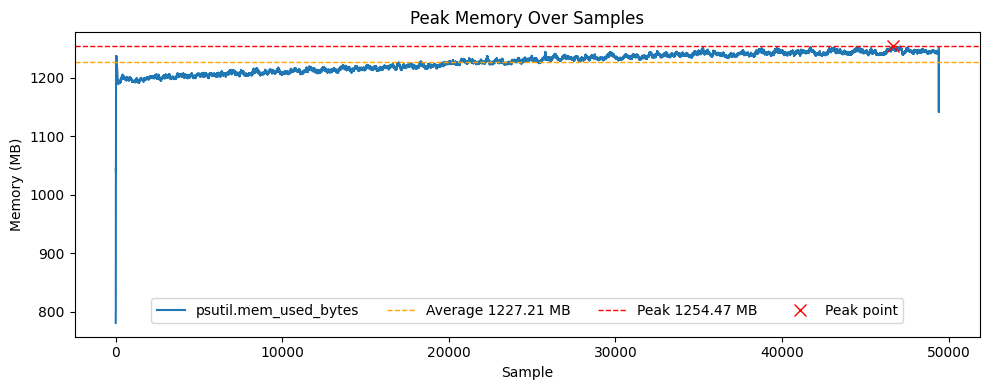

In [4]:
avg_memory_mb = float(vals_mb.mean())

fig, ax = plt.subplots(figsize=(10, 4))
vals_mb.plot(kind="line", ax=ax)
ax.axhline(avg_memory_mb, color="orange", linestyle="--", linewidth=1, label=f"Average {avg_memory_mb:.2f} MB")
ax.axhline(peak_memory_mb, color="red", linestyle="--", linewidth=1, label=f"Peak {peak_memory_mb:.2f} MB")
ax.plot(peak_idx, peak_memory_mb, marker="x", color="red", markersize=8, linestyle="None", label="Peak point")
ax.set_title("Peak Memory Over Samples")
ax.set_xlabel("Sample")
ax.set_ylabel("Memory (MB)")
ax.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, 0.15), frameon=True)
plt.tight_layout()
plt.show()

In [5]:
power_metrics = pd.read_csv(f'../results/cifar100/{rpi_device}_{model}_power_consumption_metrics.csv')

power_col = 'Power (W)'
if power_col not in power_metrics.columns:
    raise ValueError(f"Column '{power_col}' not found. Available columns: {list(power_metrics.columns)}")

power_values = pd.to_numeric(power_metrics[power_col], errors='coerce').dropna()
if power_values.empty:
    raise ValueError(f"No numeric power values found in column '{power_col}'")

if 'Time' in power_metrics.columns:
    timestamps = pd.to_datetime(power_metrics.loc[power_values.index, 'Time'])
    dt = timestamps.diff().dt.total_seconds().fillna(0)
    total_energy_j = float((power_values.values * dt.values).sum())
else:
    raise ValueError("No 'Time' column found to integrate power over time")

energy_per_sample_j = total_energy_j / 50000

print(f"Power column: {power_col}")
print(f"Total energy for 1 epoch (J): {total_energy_j:.6f}")
print(f"Energy required for 1 sample (J): {energy_per_sample_j:.9f}")
print(f"Energy required for 1 sample (mJ): {energy_per_sample_j * 1000:.6f}")

Power column: Power (W)
Total energy for 1 epoch (J): 52145.488300
Energy required for 1 sample (J): 1.042909766
Energy required for 1 sample (mJ): 1042.909766


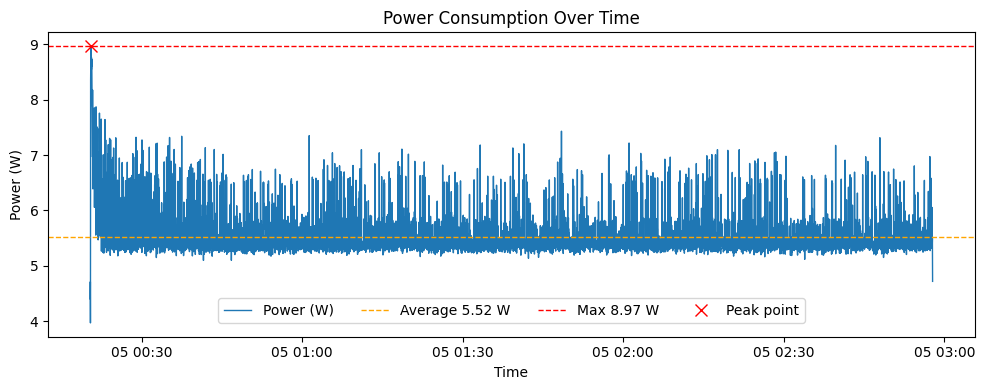

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(timestamps, power_values, linewidth=1, label="Power (W)")
ax.axhline(power_values.mean(), color="orange", linestyle="--", linewidth=1, label=f"Average {power_values.mean():.2f} W")
ax.axhline(power_values.max(), color="red", linestyle="--", linewidth=1, label=f"Max {power_values.max():.2f} W")

max_idx = power_values.idxmax()
ax.plot(timestamps.loc[max_idx], power_values.loc[max_idx], marker="x", color="red", markersize=8, linestyle="None", label="Peak point")

ax.set_title("Power Consumption Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
ax.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, 0.15), frameon=True)
plt.tight_layout()
plt.show()

## NVIDIA Jetson Orin Nano platform metrics

In [7]:
# Load and analyze jetson_metrics.csv
df_jetson = pd.read_csv(f'../results/cifar100/orin_nano_{model}_platform_metrics.csv')

# Find peak memory column
candidates_jetson = {c.lower(): c for c in df_jetson.columns}
col_mem = None
for name in ('jetson.mem'):#, 'psutil.mem_used_bytes'):
    if name in candidates_jetson:
        col_mem = candidates_jetson[name]
        break
if col_mem is None:
    col_mem = next((
        c for c in df_jetson.columns
        if 'mem' in c.lower() and ('used' in c.lower() or 'rss' in c.lower())
    ), None)

if col_mem is None:
    raise ValueError(f"No memory column found. Available columns: {list(df_jetson.columns)}")

# Parse memory values
assume_bytes_jetson = 'bytes' in col_mem.lower()
vals_mem_jetson = df_jetson[col_mem].map(lambda x: _parse_mem_to_mb(x, assume_bytes=assume_bytes_jetson)).dropna()
peak_memory_jetson = float(vals_mem_jetson.max())
peak_idx_jetson = int(vals_mem_jetson.idxmax())

print("Jetson Metrics Summary:")
print(f"Peak Memory (MB): {peak_memory_jetson:.2f}")

Jetson Metrics Summary:
Peak Memory (MB): 1982.32


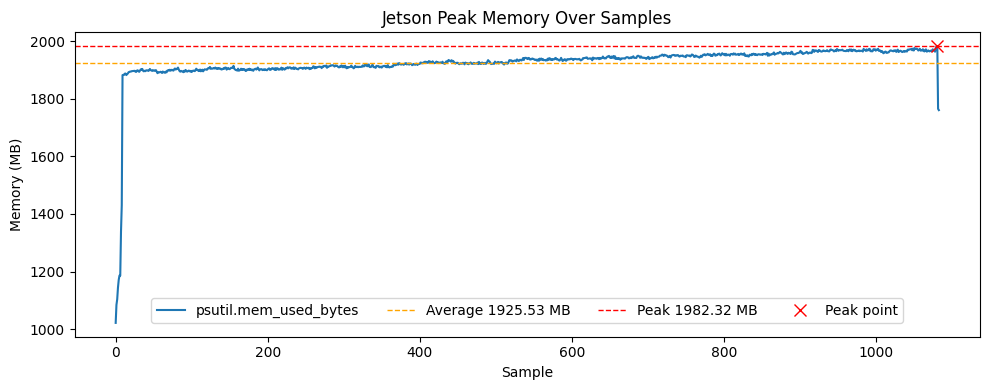

In [8]:
avg_memory_jetson = float(vals_mem_jetson.mean())

fig, ax = plt.subplots(figsize=(10, 4))
vals_mem_jetson.plot(kind="line", ax=ax)
ax.axhline(avg_memory_jetson, color="orange", linestyle="--", linewidth=1, label=f"Average {avg_memory_jetson:.2f} MB")
ax.axhline(peak_memory_jetson, color="red", linestyle="--", linewidth=1, label=f"Peak {peak_memory_jetson:.2f} MB")
ax.plot(peak_idx_jetson, peak_memory_jetson, marker="x", color="red", markersize=8, linestyle="None", label="Peak point")
ax.set_title("Jetson Peak Memory Over Samples")
ax.set_xlabel("Sample")
ax.set_ylabel("Memory (MB)")
ax.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, 0.15), frameon=True)
plt.tight_layout()
plt.show()

In [9]:
# Extract total power data and convert to numeric
power_data = pd.to_numeric(df_jetson['jetson.power_watts.tot'], errors='coerce').dropna() / 1000  # Convert mW to W

# Calculate energy in Joules
# Energy (J) = Power (W) * Time (s)
# Assuming samples are recorded at regular intervals, calculate time difference
timestamps = pd.to_datetime(df_jetson['timestamp'])
time_intervals = timestamps.diff().dt.total_seconds().fillna(0)

# Energy per sample (in Joules)
energy_per_sample = power_data.values * time_intervals[power_data.index].values

# Total energy (J)
total_energy_j = energy_per_sample.sum()

# Energy per sample per epoch
num_epochs = 1
num_batches = 50000
samples_per_epoch = num_batches  # Assuming 1 sample per batch for simplicity

energy_per_sample_per_epoch = total_energy_j / (num_epochs * samples_per_epoch)

print(f"Total Energy Consumed (J): {total_energy_j:.2f}")
print(f"Energy per Sample per Epoch (J): {energy_per_sample_per_epoch:.6f}")
print(f"Energy per Sample per Epoch (mJ): {energy_per_sample_per_epoch * 1000:.3f}")

Total Energy Consumed (J): 11704.72
Energy per Sample per Epoch (J): 0.234094
Energy per Sample per Epoch (mJ): 234.094


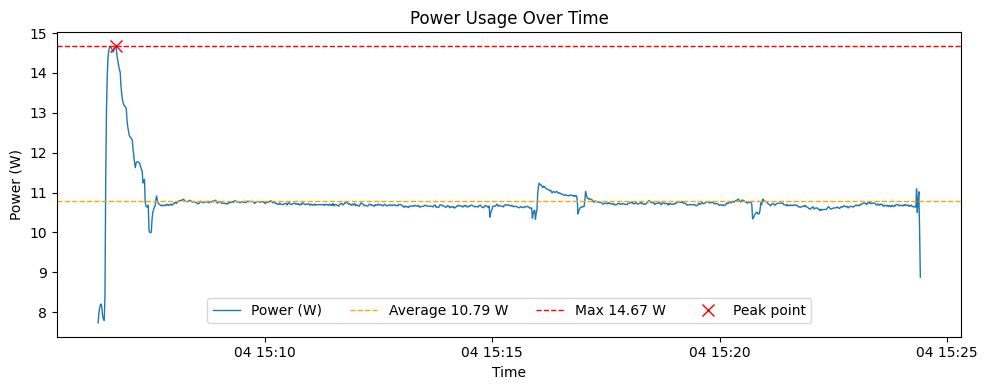

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timestamps, power_data, linewidth=1, label="Power (W)")

avg_power = power_data.mean()
max_power = power_data.max()
max_idx_power = power_data.idxmax()

ax.axhline(avg_power, color="orange", linestyle="--", linewidth=1, label=f"Average {avg_power:.2f} W")
ax.axhline(max_power, color="red", linestyle="--", linewidth=1, label=f"Max {max_power:.2f} W")
ax.plot(timestamps.loc[max_idx_power], power_data.loc[max_idx_power], marker="x", color="red", markersize=8, linestyle="None", label="Peak point")

ax.set_title("Power Usage Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, 0.15), frameon=True)
plt.tight_layout()
plt.show()